<h1 style = "color: blue;"><strong><em><center>Spotify Project - Analyzing The Characteristics Of Spotify Songs</strong></em></center></h1>

<h2 style = "color: gold;"><strong><center>Statistical Investigation Question:</center></strong></h2>

<h3 style = "color: blue;"><em><center>According to the Spotify CSV file about data from 2023's top songs, what is the mean, median, and mode of ALL danceability percentages?</center></em></h3>

<h2 style = "color: gold;"><strong><center>Type of Study:</center></strong></h2>

<h3 style = "color: blue;"><em><center>The type of study I plan to conduct is an observational study because I'm only using a sample of Spotify data, rather than every single piece of data out of Spotify. Specifically, I'm using the data from 2023's most popular songs on Spotify. I don't have access to ALL songs on Spotify from 2023, signifying it's an observational study and NOT a census.</center></em></h3>

In [56]:
import pandas as pd
import seaborn as sns

In [57]:
spotify = pd.read_csv("spotify-2023.csv", encoding = "latin1")

In [58]:
spotify = pd.read_csv("spotify-2023.csv", encoding = "latin1")

In [59]:
danceability_mean = spotify["danceability_%"].mean()

In [60]:
danceability_min = spotify["danceability_%"].median()

In [61]:
danceability_mode = spotify["danceability_%"].mode()

In [62]:
danceability_min = spotify["danceability_%"].min()

In [63]:
danceability_max = spotify["danceability_%"].max()

In [64]:
danceability_quantile = spotify["danceability_%"].quantile()

<h2 style = "color: gold;"><strong><center>7-Number Summary - Danceability Characteristics</center></strong></h2>

In [65]:
print(danceability_mean)
print(danceability_min)
print(danceability_mode)
print(danceability_min)
print(danceability_max)
print(danceability_quantile)

66.96956977964324
23
0    70
Name: danceability_%, dtype: int64
23
96
69.0


<h2 style = "color: gold;"><strong><center>Histogram Graph (Using Mean, Median, & Mode):</center></strong></h2>

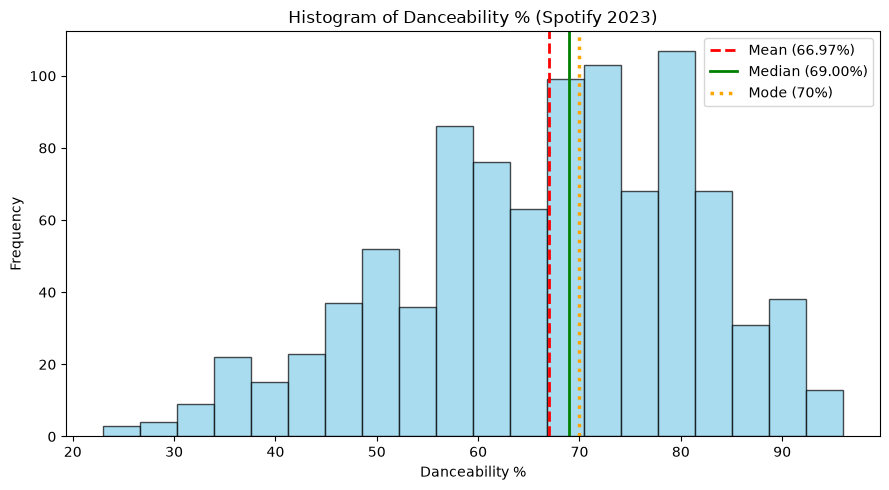

In [66]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

# 1. Load data
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')
dance = df['danceability_%'].dropna()

# 2. Calculate summary statistics
mean_val = dance.mean()
median_val = dance.median()
mode_val = dance.mode()[0]

# 3. Create and display the plot
plt.figure(figsize=(9, 5))
plt.hist(dance, bins=20, color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean ({mean_val:.2f}%)',
)
plt.axvline(
    median_val,
    color='green',
    linestyle='-',
    linewidth=2,
    label=f'Median ({median_val:.2f}%)',
)
plt.axvline(
    mode_val,
    color='orange',
    linestyle=':',
    linewidth=2.5,
    label=f'Mode ({mode_val}%)',
)

plt.title('Histogram of Danceability % (Spotify 2023)')
plt.xlabel('Danceability %')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load data & calculate statistics
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')
dance = df['danceability_%'].dropna()

mean_val = dance.mean()
median_val = dance.median()
mode_val = dance.mode()[0]

# 2. Print summary statistics
print(
    f'Mean: {mean_val:.2f}% | Median: {median_val:.2f}% | Mode: {mode_val}%\n'
)


# 3. Build & print Ultra-Split Stem-and-Leaf table
def print_ultra_split_stem_and_leaf(data):
  stems = {}
  for val in sorted(data):
    val_int = int(val)
    stem_base = val_int // 10
    sub_index = (
        val_int % 10
    ) // 2  # Breaks each decade into 5 bins (0-1, 2-3, 4-5, 6-7, 8-9)
    leaf = val_int % 10

    stems.setdefault((stem_base, sub_index), []).append(str(leaf))

  print('Stem | Leaf')
  print('-' * 60)

  labels = ['a', 'b', 'c', 'd', 'e']
  for stem_base, sub_index in sorted(stems.keys()):
    leaves = ''.join(stems[(stem_base, sub_index)])
    label = f'{stem_base}{labels[sub_index]}'
    print(f'{label:>4s} | {leaves}')


print_ultra_split_stem_and_leaf(dance)

Mean: 66.97% | Median: 69.00% | Mode: 70%

Stem | Leaf
------------------------------------------------------------
  2b | 3
  2c | 45
  2d | 7
  2e | 889
  3a | 1111
  3b | 22333
  3c | 444444455555
  3d | 6666777777
  3e | 89999
  4a | 0000011111
  4b | 22222233333
  4c | 4444444444445555555555555
  4d | 666666667777777777
  4e | 88888899999999999
  5a | 000000000000111111111111111111
  5b | 2222222222233333333333333333
  5c | 4444444444555555555
  5d | 6666666666666666666666666666667777777777777777
  5e | 8888888888888889999999999999999999999999
  6a | 000000000000000000000011111111111111111111
  6b | 2222222222233333333333333333333333
  6c | 4444444444444444444455555555555555555555555555
  6d | 6666666666666666677777777777777777777777
  6e | 888888888888888888889999999999999
  7a | 000000000000000000000000000000000000000000011111111111111111111111111
  7b | 222222222222222222222333333333333333333333333333
  7c | 444444444444444444444444444445555555555555555555
  7d | 66666666666666

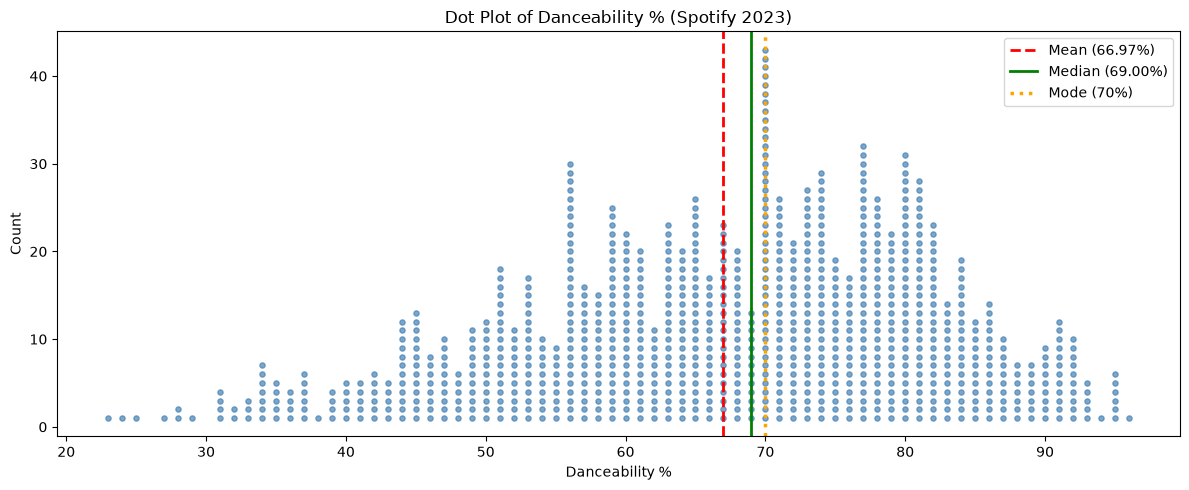

In [68]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load data & calculate statistics
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')
dance = df['danceability_%'].dropna()

mean_val = dance.mean()
median_val = dance.median()
mode_val = dance.mode()[0]

# 2. Construct dot plot coordinates
counts = dance.value_counts().sort_index()
x_dots, y_dots = [], []

for val, count in counts.items():
  for i in range(count):
    x_dots.append(val)
    y_dots.append(i + 1)

# 3. Render Dot Plot with Mean, Median, and Mode lines
plt.figure(figsize=(12, 5))
plt.scatter(x_dots, y_dots, s=14, color='steelblue', alpha=0.7)

plt.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean ({mean_val:.2f}%)',
)
plt.axvline(
    median_val,
    color='green',
    linestyle='-',
    linewidth=2,
    label=f'Median ({median_val:.2f}%)',
)
plt.axvline(
    mode_val,
    color='orange',
    linestyle=':',
    linewidth=2.5,
    label=f'Mode ({mode_val}%)',
)

plt.title('Dot Plot of Danceability % (Spotify 2023)')
plt.xlabel('Danceability %')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

<h2 style = "color: gold;"><strong><center>Conclusion:</center></strong></h2>

<h3 style = "color: blue;"><em><center>In summary, the mean of ALL danceability percentages of Spotify's most popular songs in 2023 is approximately 66.97%. The median is 69.00%, and the mode is 70%.
The histogram graph for my target variable (danceability percentages) is located below.
Interpretation of histogram graph: The graph is left-skewed because there's a more visible increase compared to the decrease in danceability percentages. Because it's skewed left, the mean is less than the median. Interpretation of stem-and-leaf plot: There are many numbers attached to where the 7a stem is. The same trend follows with the 8a stem as well. According to the numerical representation, there are many numbers attached to this stem.
Interpretation of dot plot: The graph increases up to the point in which it reaches the mean. From the mean to about where the 80% danceability percentage is located, there's a slow increase before decreasing after 80%.
</center></em></h3>

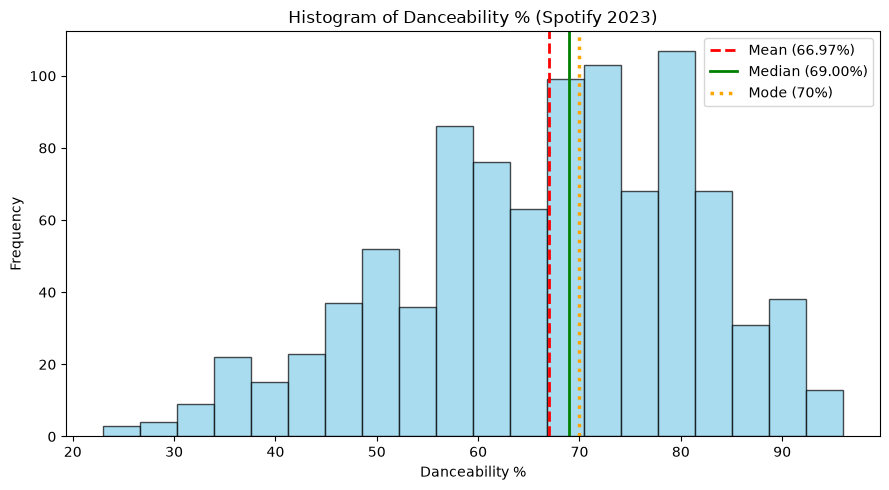

In [69]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

# 1. Load data
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')
dance = df['danceability_%'].dropna()

# 2. Calculate summary statistics
mean_val = dance.mean()
median_val = dance.median()
mode_val = dance.mode()[0]

# 3. Create and display the plot
plt.figure(figsize=(9, 5))
plt.hist(dance, bins=20, color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean ({mean_val:.2f}%)',
)
plt.axvline(
    median_val,
    color='green',
    linestyle='-',
    linewidth=2,
    label=f'Median ({median_val:.2f}%)',
)
plt.axvline(
    mode_val,
    color='orange',
    linestyle=':',
    linewidth=2.5,
    label=f'Mode ({mode_val}%)',
)

plt.title('Histogram of Danceability % (Spotify 2023)')
plt.xlabel('Danceability %')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()